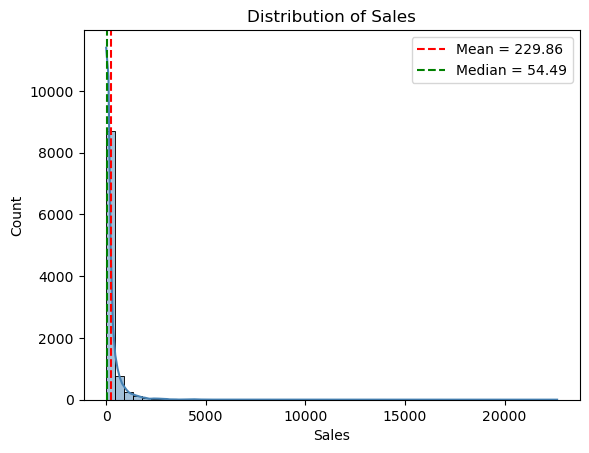

In [7]:
#1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
sales = data['Sales']

mean = sales.mean()
median = sales.median()
skewness = skew(sales)

sns.histplot(sales, kde=True, bins=50, color='steelblue')
plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
plt.axvline(median, color='green', linestyle='--', label=f'Median = {median:.2f}')
plt.title('Distribution of Sales')
plt.legend()
plt.show()

The distribution is heavily right-skewed (skewness ≈ 13, and mean >> median). This is because most orders are small but a few  large orders pull the mean up.  mean is far above median, mean is not a good here  median is more reliable, as mean gets distorted by the extreme high-value outliers.

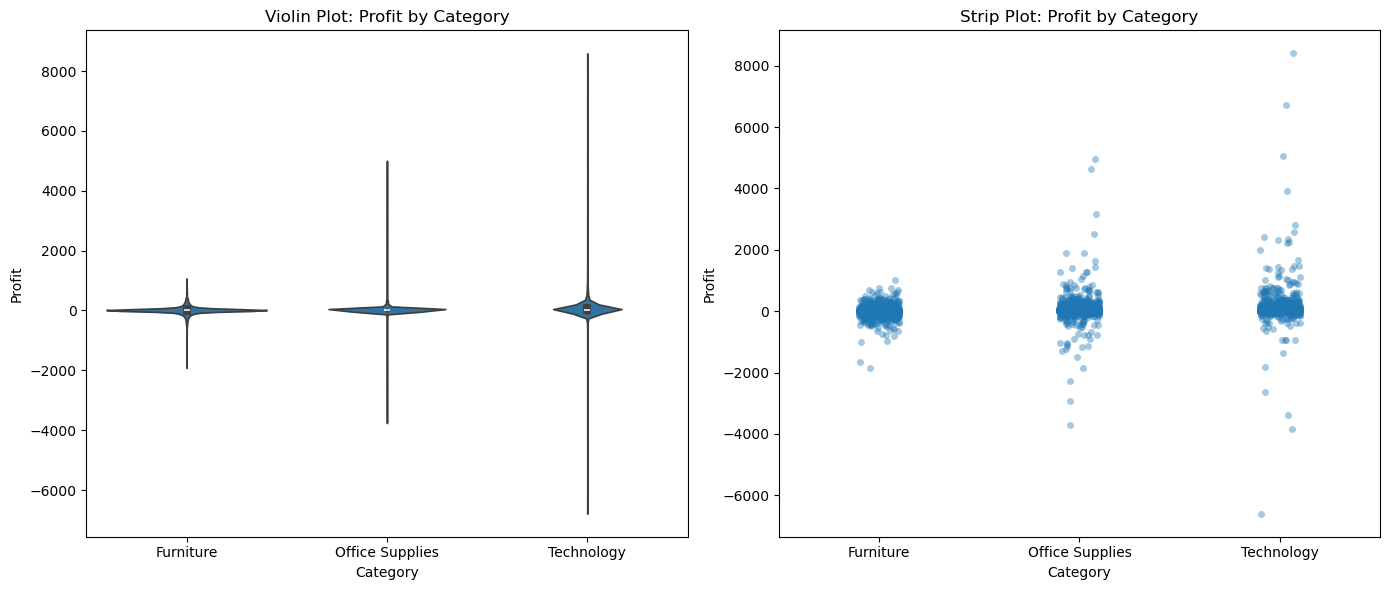

In [8]:
#2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=data, x='Category', y='Profit', ax=axes[0])
axes[0].set_title('Violin Plot: Profit by Category')

sns.stripplot(data=data, x='Category', y='Profit', jitter=True, alpha=0.4, ax=axes[1])
axes[1].set_title('Strip Plot: Profit by Category')

plt.tight_layout()
plt.show()

The violin plot better reveals the shape of the distribution Furniture shows a wide flat body with a long tail hinting at spread out  which the strip plot only shows as a scattered cloud of dots without a clear shape.

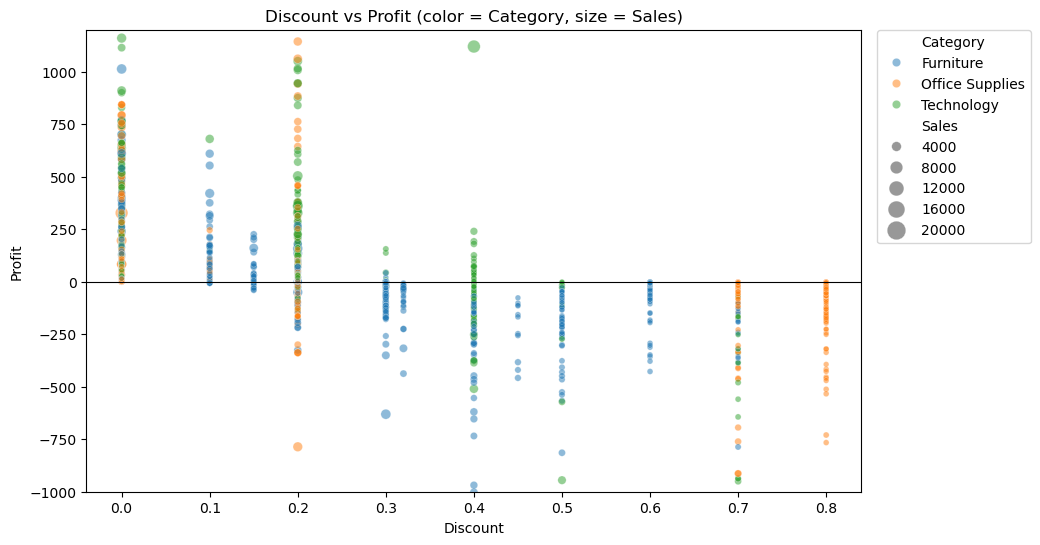

In [9]:
#3
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='Discount',
    y='Profit',
    hue='Category',       # 3rd variable: color by category
    size='Sales',         # 4th variable: point size by sales
    sizes=(15, 200),
    alpha=0.5,
    edgecolor='white',
    linewidth=0.3
)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylim(-1000, 1200)   
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title('Discount vs Profit (color = Category, size = Sales)')
plt.show()

 The 4 variable encoding shows that the biggest losses (large negative profit) mostly happen on large sized points  that are also Furniture or Technology at high discount  meaning big, high-value orders lose the most money when heavily discounted. 

In [18]:
#4
import pandas as pd

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
numeric = data[['Sales', 'Quantity', 'Discount', 'Profit']]

pearson = numeric.corr(method='pearson')
spearman = numeric.corr(method='spearman')

The two disagree a lot for Discount vs Profit. The scatter shows the relationship is not a straight line  profit drops sharply and becomes very negative once discount crosses a certain point and there are also some extreme negative profit outliers at high discount. Pearson only measures straight-line relationships, so it gets weakened by the non-linearity and outliers. Spearman measures whether the rank order goes consistently down as discount rises, which it does more clearly, so it picks up a stronger relationship.

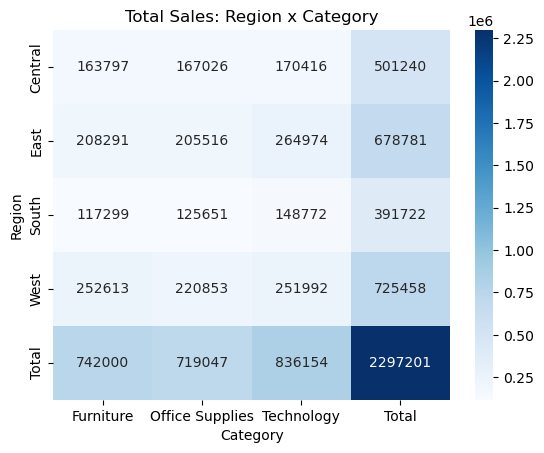

In [13]:
#5
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

table = pd.pivot_table(
    data,
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)

sns.heatmap(table, annot=True, fmt='.0f', cmap='Blues')
plt.title('Total Sales: Region x Category')
plt.show()

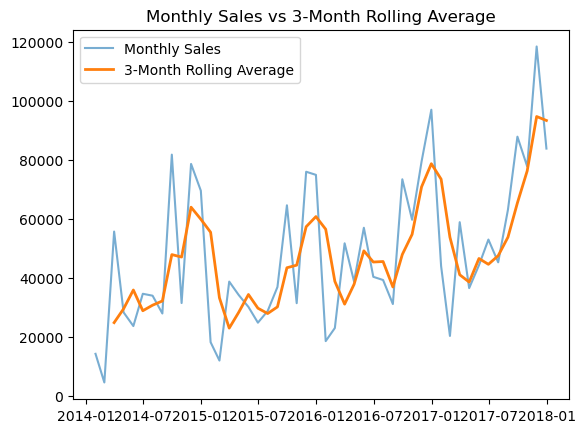

In [15]:
#6
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
data['Order Date'] = pd.to_datetime(data['Order Date'])
data = data.set_index('Order Date')

monthly = data['Sales'].resample('ME').sum()
rolling = monthly.rolling(window=3).mean()

plt.plot(monthly, label='Monthly Sales', alpha=0.6)
plt.plot(rolling, label='3-Month Rolling Average', linewidth=2)
plt.legend()
plt.title('Monthly Sales vs 3-Month Rolling Average')
plt.show()

The raw monthly line jumps up and down sharply month to month, making it hard to tell if sales are really growing. The rolling average smooths out this noise and reveals a clear underlying upward trend, with sales peaking around November December each year

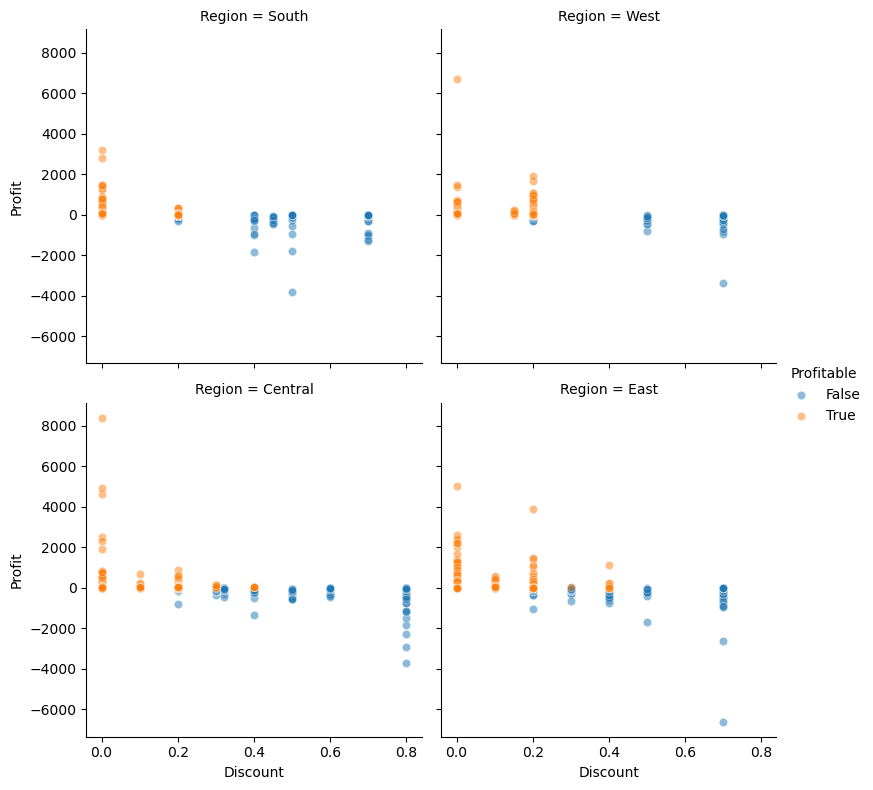

In [16]:
#7
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
data['Profitable'] = data['Profit'] > 0

grid = sns.FacetGrid(data, col='Region', hue='Profitable', col_wrap=2, height=4)
grid.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.5)
grid.add_legend()
plt.show()

Central region stands out it shows losses (unprofitable orders) starting at much lower discount levels compared to other regions, where losses only appear once discount gets quite high. This suggests Central is more sensitive to discounting than the rest.

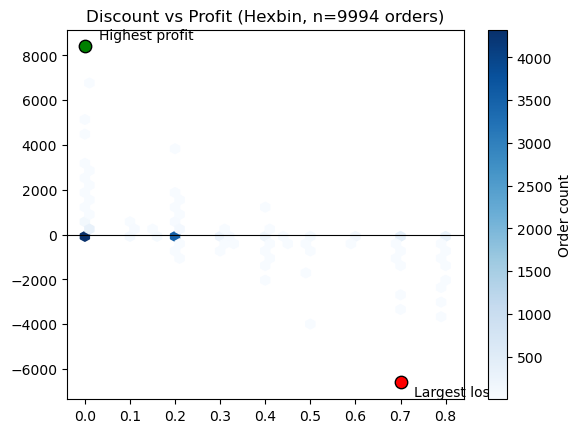

In [17]:
#8
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

maxRow = data.loc[data['Profit'].idxmax()]
minRow = data.loc[data['Profit'].idxmin()]

hb = plt.hexbin(data['Discount'], data['Profit'], gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Order count')

plt.scatter(maxRow['Discount'], maxRow['Profit'], color='green', s=80, edgecolor='black')
plt.annotate('Highest profit', (maxRow['Discount'], maxRow['Profit']), xytext=(10, 5), textcoords='offset points')

plt.scatter(minRow['Discount'], minRow['Profit'], color='red', s=80, edgecolor='black')
plt.annotate('Largest loss', (minRow['Discount'], minRow['Profit']), xytext=(10, -10), textcoords='offset points')

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Discount vs Profit (Hexbin, n=9994 orders)')
plt.show()